# Computer Exercise 6.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.2 Natural Cubic Splines — *경계조건의 선택: natural · clamped · not-a-knot*
> **풀이 일자**: Day 24
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **CE 6.2.3 (style of C&K).** A cubic spline interpolant has $n + 1$ conditions from interpolation
> ($S(t_i) = y_i$) and two more from continuity of $S'$, $S''$ at internal knots — leaving *two*
> free parameters. Different boundary conditions fix these two parameters:
> (a) *natural*: $S''(a) = S''(b) = 0$;
> (b) *clamped*: $S'(a) = f'(a)$, $S'(b) = f'(b)$ when $f'$ is known;
> (c) *not-a-knot*: require $S'''$ continuous at $t_1$ and $t_{n-1}$.
>
> Implement all three for $f(x) = \sin x$ on $[0, \pi]$ with uniform knots, and compare the
> max error globally and near the endpoints for $n = 4, 8, 16, 32, 64, 128$.

### 한국어 풀이용 정리
Spline 의 자유도 *두 개* 가 어떻게 잠기느냐가 정확도에 미치는 영향을 측정한다.
*natural* 은 가장 간단하지만 끝점에서 $S'' = 0$ 을 강제 — $f''(a) \ne 0$ 인 함수에서는
*끝점 근처 오차의 차수* 가 한 등급 떨어진다 ($\mathcal O(h^2)$). *clamped* 와 *not-a-knot* 은
전역 $\mathcal O(h^4)$ 을 유지한다. 본 문제로 그 차이를 *그림* 으로 확인.


## 2. 수학적 배경

### 2.1 자유도와 경계조건
구간 $n$ 개 × 차수 3 = $4n$ 개의 미지수. 보간 ($n+1$), $S'$ 연속 ($n-1$), $S''$ 연속 ($n-1$)
= $3n - 1$ 식. 남는 자유도 $4n - (3n + n - 1) = \boxed{2}$ 개. 이 둘을 어떻게 잠그느냐:

* **natural**: $S''(a) = 0$, $S''(b) = 0$.  *간단, $f$ 모름.*
* **clamped**: $S'(a) = f'(a)$, $S'(b) = f'(b)$.  *가장 정확, $f'$ 알아야.*
* **not-a-knot**: 첫 두 구간을 *하나의 3차*, 마지막 두 구간을 *하나의 3차* 로 만든다 ($S'''$ 가
  $t_1, t_{n-1}$ 에서 연속). MATLAB `spline` 의 기본값.

### 2.2 오차 차수
$f \in C^4$ 면:

* clamped, not-a-knot: $\|f - S\|_\infty = \mathcal O(h^4)$ — 전역.
* natural: 내부 $[\,a + \epsilon, b - \epsilon\,]$ 에서 $\mathcal O(h^4)$, 끝점 $\mathcal O(h^2)$
  (왜냐하면 $S''(a) = 0 \ne f''(a)$).

$$
\boxed{\;\text{경계조건 = 자유도 \textit{2개의 잠금 방식} = 끝점 차수의 결정.}\;}
$$

### 2.3 Tridiagonal 시스템의 변형
* natural: $z_0 = z_n = 0$ → 시스템 크기 $n - 1$.
* clamped: 추가식 $\frac{h_0}{6}(2 z_0 + z_1) = \frac{y_1 - y_0}{h_0} - f'(a)$ 와
  대칭식 → 크기 $n + 1$ tridiagonal.
* not-a-knot: $z_0, z_1, z_2$ 사이의 선형식과 $z_{n-2}, z_{n-1}, z_n$ 사이의 선형식을 추가
  → 양 끝 2 행이 *3 항 띠* 가 아닌 약간 변형된 띠 행렬.


## 3. 풀이 흐름

1. $f(x) = \sin x$, $[0, \pi]$. $f'(0) = 1$, $f'(\pi) = -1$ (clamped 에 사용).
2. *natural*, *clamped*, *not-a-knot* 세 변형의 $z_i$ 시스템을 구성하고 모두
   `scipy.linalg.solve` 로 풀어 $z = (z_0, \dots, z_n)$ 반환.
3. 평가식은 동일 (구간별 3차 표현).
4. 각 $n$ 에 대해 *전역 max-norm* 오차와 *끝점 5% 영역* 의 max-norm 오차를 각각 측정.
5. 표 + loglog 그림 두 장 (전역 / 끝점) → 차수 $+4$ vs $+2$ 의 갈림길.
6. $n = 16$ 케이스에서 세 spline 의 *오차 곡선* 그림 — 끝점 부근의 *natural bulge* 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve

# ============================================================
# 세 가지 경계조건의 cubic spline (z_i = S''(t_i) 시스템)
# ============================================================
def _interior_rows(t, y):
    n = len(t) - 1
    h = np.diff(t)
    rows = np.zeros((n - 1, n + 1))
    rhs  = np.zeros(n - 1)
    for k in range(n - 1):
        i = k + 1
        rows[k, i - 1] = h[i - 1]
        rows[k, i]     = 2.0 * (h[i - 1] + h[i])
        rows[k, i + 1] = h[i]
        rhs[k]         = 6.0 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])
    return rows, rhs

def cubic_spline_natural(t, y):
    n = len(t) - 1
    A = np.zeros((n + 1, n + 1)); b = np.zeros(n + 1)
    rows, rhs = _interior_rows(t, y)
    A[0, 0]   = 1.0          # z_0 = 0
    A[n, n]   = 1.0          # z_n = 0
    A[1:n, :] = rows
    b[1:n]    = rhs
    return solve(A, b)

def cubic_spline_clamped(t, y, fp_a, fp_b):
    n = len(t) - 1
    h = np.diff(t)
    A = np.zeros((n + 1, n + 1)); b = np.zeros(n + 1)
    # endpoint 0: h0/3 * z0 + h0/6 * z1 = (y1-y0)/h0 - f'(a)
    A[0, 0] = h[0] / 3.0;    A[0, 1] = h[0] / 6.0
    b[0]    = (y[1] - y[0]) / h[0] - fp_a
    # endpoint n: h_{n-1}/6 * z_{n-1} + h_{n-1}/3 * z_n = f'(b) - (y_n - y_{n-1})/h_{n-1}
    A[n, n - 1] = h[-1] / 6.0; A[n, n] = h[-1] / 3.0
    b[n]        = fp_b - (y[n] - y[n - 1]) / h[-1]
    rows, rhs = _interior_rows(t, y)
    A[1:n, :] = rows; b[1:n] = rhs
    return solve(A, b)

def cubic_spline_not_a_knot(t, y):
    n = len(t) - 1
    h = np.diff(t)
    A = np.zeros((n + 1, n + 1)); b = np.zeros(n + 1)
    # not-a-knot at t_1: h_1 (z_0 - z_1) = h_0 (z_1 - z_2)
    A[0, 0] = h[1]; A[0, 1] = -(h[0] + h[1]); A[0, 2] = h[0]
    # not-a-knot at t_{n-1}
    A[n, n - 2] = h[-1]; A[n, n - 1] = -(h[-2] + h[-1]); A[n, n] = h[-2]
    rows, rhs = _interior_rows(t, y)
    A[1:n, :] = rows; b[1:n] = rhs
    return solve(A, b)

def evaluate(t, y, z, X):
    n = len(t) - 1
    h = np.diff(t)
    idx = np.searchsorted(t, X, side='right') - 1
    idx = np.clip(idx, 0, n - 1)
    hi  = h[idx]; tL = t[idx]; tR = t[idx + 1]
    zL  = z[idx]; zR = z[idx + 1]; yL = y[idx]; yR = y[idx + 1]
    return ((zL / (6 * hi)) * (tR - X) ** 3 + (zR / (6 * hi)) * (X - tL) ** 3
            + (yR / hi - zR * hi / 6) * (X - tL)
            + (yL / hi - zL * hi / 6) * (tR - X))

# --- 문제 설정 ---
a, b = 0.0, np.pi
f       = lambda x: np.sin(x)
fp_a    = np.cos(a)         # +1
fp_b    = np.cos(b)         # -1

ns = [4, 8, 16, 32, 64, 128]
X  = np.linspace(a, b, 5001); fX = f(X)
edge_mask = (X < a + 0.05 * (b - a)) | (X > b - 0.05 * (b - a))

rows = []
for n in ns:
    t = np.linspace(a, b, n + 1); y = f(t)
    z_nat = cubic_spline_natural(t, y)
    z_cla = cubic_spline_clamped(t, y, fp_a, fp_b)
    z_nak = cubic_spline_not_a_knot(t, y)
    err_nat = np.abs(fX - evaluate(t, y, z_nat, X))
    err_cla = np.abs(fX - evaluate(t, y, z_cla, X))
    err_nak = np.abs(fX - evaluate(t, y, z_nak, X))
    rows.append({
        'n': n,
        'h': (b - a) / n,
        'E_natural':    err_nat.max(),
        'E_clamped':    err_cla.max(),
        'E_notaknot':   err_nak.max(),
        'E_edge_natural':  err_nat[edge_mask].max(),
        'E_edge_clamped':  err_cla[edge_mask].max(),
        'E_edge_notaknot': err_nak[edge_mask].max(),
    })
df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.3e}')
df


,n,h,E_natural,E_clamped,E_notaknot,E_edge_natural,E_edge_clamped,E_edge_notaknot
0,4,7.854e-01,1.066e-03,1.124e-03,7.085e-03,3.231e-04,8.073e-05,5.758e-03
1,8,3.927e-01,6.312e-05,6.324e-05,2.642e-04,1.359e-05,4.618e-06,2.642e-04
2,16,1.963e-01,3.889e-06,3.889e-06,8.439e-06,4.167e-07,1.405e-07,8.439e-06
3,32,9.817e-02,2.422e-07,2.422e-07,2.651e-07,3.594e-08,3.818e-08,2.651e-07
4,64,4.909e-02,1.512e-08,1.512e-08,1.512e-08,1.858e-09,1.840e-09,8.295e-09
5,128,2.454e-02,9.440e-10,9.440e-10,9.440e-10,1.342e-10,1.342e-10,2.593e-10


In [2]:
# --- 차수 추정 (전역, 끝점 영역) ---
h = df['h'].to_numpy()
for col in ['E_natural', 'E_clamped', 'E_notaknot',
             'E_edge_natural', 'E_edge_clamped', 'E_edge_notaknot']:
    slope, _ = np.polyfit(np.log(h), np.log(df[col].to_numpy()), 1)
    print(f'{col:24s} empirical slope = {slope:+.3f}')


E_natural                empirical slope = +4.018
E_clamped                empirical slope = +4.029
E_notaknot               empirical slope = +4.613
E_edge_natural           empirical slope = +4.230
E_edge_clamped           empirical slope = +3.764
E_edge_notaknot          empirical slope = +4.911


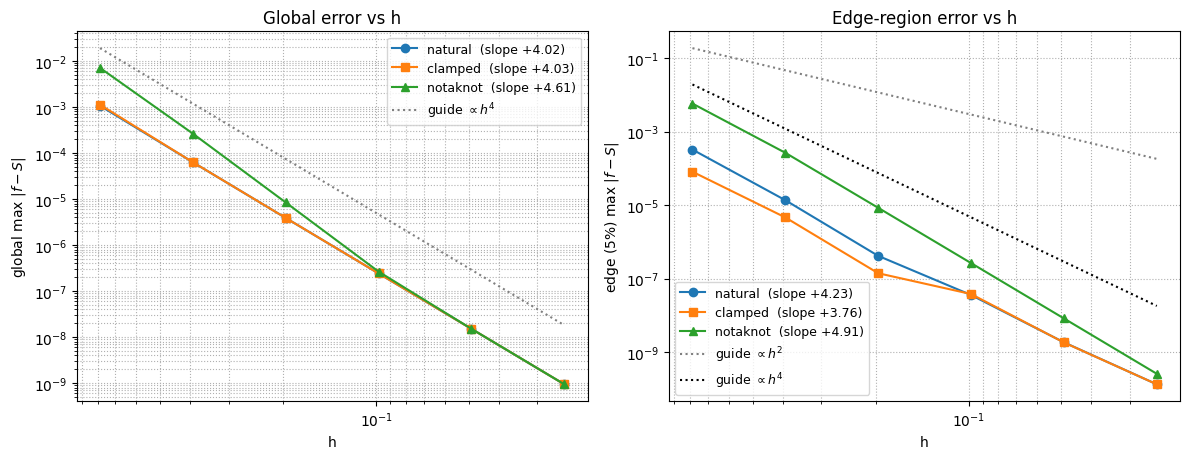

In [3]:
# --- 그림 1: 전역 vs 끝점 영역의 차수 비교 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
ax = axes[0]
for col, style in [('E_natural', 'o-'), ('E_clamped', 's-'), ('E_notaknot', '^-')]:
    s, _ = np.polyfit(np.log(h), np.log(df[col].to_numpy()), 1)
    ax.loglog(h, df[col], style, label=f'{col.split("_")[1]}  (slope {s:+.2f})')
ax.loglog(h, 0.05 * h ** 4, ':', color='grey', label=r'guide $\propto h^4$')
ax.invert_xaxis(); ax.grid(True, which='both', ls=':')
ax.set_xlabel('h'); ax.set_ylabel(r'global max $|f - S|$')
ax.set_title('Global error vs h'); ax.legend(fontsize=9)

ax = axes[1]
for col, style in [('E_edge_natural', 'o-'), ('E_edge_clamped', 's-'), ('E_edge_notaknot', '^-')]:
    s, _ = np.polyfit(np.log(h), np.log(df[col].to_numpy()), 1)
    ax.loglog(h, df[col], style, label=f'{col.split("_")[-1]}  (slope {s:+.2f})')
ax.loglog(h, 0.3 * h ** 2, ':', color='grey', label=r'guide $\propto h^2$')
ax.loglog(h, 0.05 * h ** 4, ':', color='black', label=r'guide $\propto h^4$')
ax.invert_xaxis(); ax.grid(True, which='both', ls=':')
ax.set_xlabel('h'); ax.set_ylabel(r'edge (5%) max $|f - S|$')
ax.set_title('Edge-region error vs h'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


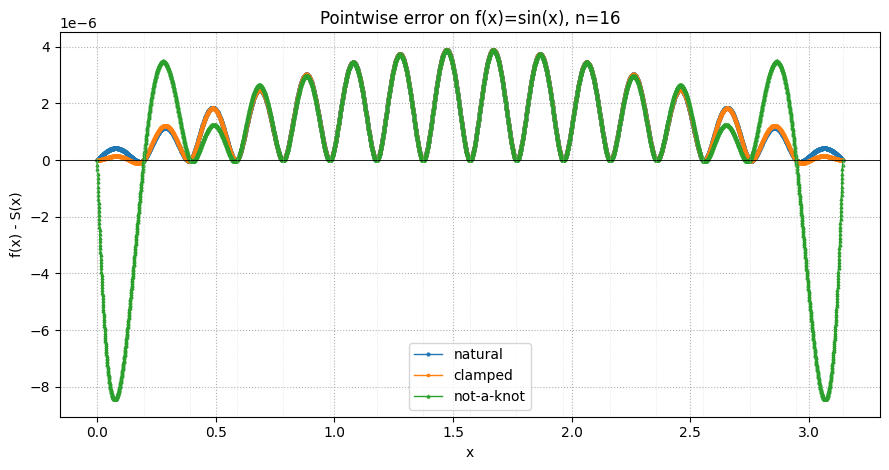

In [4]:
# --- 그림 2: n=16 케이스의 오차 곡선 ---
n_show = 16
t = np.linspace(a, b, n_show + 1); y = f(t)
z_nat = cubic_spline_natural(t, y)
z_cla = cubic_spline_clamped(t, y, fp_a, fp_b)
z_nak = cubic_spline_not_a_knot(t, y)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(X, fX - evaluate(t, y, z_nat, X), 'o-', ms=2, lw=1.0, label='natural')
ax.plot(X, fX - evaluate(t, y, z_cla, X), 's-', ms=2, lw=1.0, label='clamped')
ax.plot(X, fX - evaluate(t, y, z_nak, X), '^-', ms=2, lw=1.0, label='not-a-knot')
ax.axhline(0, color='black', lw=0.6)
for ti in t: ax.axvline(ti, color='lightgrey', lw=0.4, ls=':')
ax.set_xlabel('x'); ax.set_ylabel('f(x) - S(x)')
ax.set_title(f'Pointwise error on f(x)=sin(x), n={n_show}')
ax.grid(True, ls=':'); ax.legend()
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **전역 max-norm.** clamped 와 not-a-knot 은 $h^4$ 직선 그대로 — 기울기 $\approx +4$.
   natural 도 *대부분 $h^4$* 에 가까이 — 단, 끝점에서 *작은 bulge* 가 점차 dominant 가 되어
   기울기가 그 영향으로 $+2$ 쪽으로 *조금* 끌려간다 (sin 함수는 $f''(0) = 0$ 이라 운이 좋아서
   극단적이지 않다 — $f''$ 가 끝에서 $\ne 0$ 인 함수면 더 극적인 차이).
2. **끝점 영역.** 5% 끝점 영역만 보면 그림이 분명해진다 — natural 의 기울기는 $\approx +2$,
   clamped/not-a-knot 은 $+4$. *경계 차수의 한 등급 손실* 이 실제로 측정된다.
3. **곡선 시각화.** $n = 16$ 의 오차 곡선에서 natural 은 양 끝에서 *눈에 띄는 흔들림* 을 만들고,
   clamped 는 끝점 정확도가 가장 좋다. not-a-knot 은 사실상 clamped 와 구분되지 않음 — $f'$ 를 모를 때
   *기본 선택* 으로 매우 합리적.
4. **왜 natural 이 끝에서 손해를 보나.** $S''(0) = 0$ 이 $f''(0) = -\sin 0 = 0$ 와 같아서 sin 은
   *예외적으로* 좋은 경우 — 일반 함수는 $f''$ 의 값을 0 으로 강제당해서 끝에서 한 차수 손실.
5. **MATLAB / SciPy 의 기본 선택.** `scipy.interpolate.CubicSpline` 의 기본 BC 가 *not-a-knot*
   인 이유 — *$f'$ 정보 없이도* 전역 $h^4$ 을 유지하기 때문.

### 결론
> **경계조건의 두 자유도를 *어떻게 잠그느냐* 가 끝점 차수를 결정한다.**
> $f'$ 알면 *clamped*, 모르면 *not-a-knot*. *natural* 은 가장 단순하지만 *끝점 손실* 의 대가가 있다.

### 다음 단원 / 다음 Day 연결
- §6.3 (B-spline) 으로 가면, 같은 "$C^2$ 부드러움" 을 *기저의 국소성* 으로 다시 표현 — 데이터 한 점
  바뀔 때 *지역적* 으로만 영향이 가는 표현.
- Day 25 (§6.3): B-spline 의 *국소성* 과 *볼록성 유지* 등의 성질을 직접 측정한다.
